# 메모리 관리

## 1. 개요

LLM API는 호출할 때마다 이전 요청과 관계없이 **완전히 독립적으로 동작**한다. 즉, 직전에 어떤 대화가 오갔는지 API 스스로는 전혀 알지 못한다.   
모델 입장에서 보면 매 호출은 "처음 만나는 사람과의 첫 마디"와 같다. 이를 가리켜 **LLM API는 상태가 없다(stateless)** 고 말한다.

이 성질은 단순 질의응답에서는 문제가 되지 않지만 챗봇처럼 대화의 맥락이 이어져야 하는 경우에는 곧바로 문제가 된다.  
사용자가 "내 이름은 밥이야"라고 말한 뒤 다음 턴에서 "내 이름이 뭐였지?"라고 물으면, 상태가 없는 모델은 답할 수 없다. 직전 대화내용이 모델에게 전달되지 않았기 때문이다.

대화의 연속성이 필요하다면, **이전 대화 내용을 애플리케이션 쪽에서 별도로 보관하고 매 요청마다 LLM에 함께 전달**해야 한다.  
챗봇 서비스에서 LLM이 이전 내용을 기억하는 것처럼 보이는 것은, 매번 과거 대화 기록을 다시 입력으로 넣어 주기 때문이다.

**메모리 관리(memory management)란** 이런 그동안의 대화 내역을 관리하는 것을 말하며, 다음 세가지를 바탕으로 설계하고 운영한다.
- **무엇을** 전달할 것인가 (전체 대화? 일부만?)
- **얼마나** 전달할 것인가 (컨텍스트 윈도가 무한하지 않다)
- **어떻게** 전달할 것인가 (원문 그대로? 요약본? 추출된 사실?)
  
메모리 관리는 단순히 "대화를 저장한다"가 아니라, **한정된 컨텍스트 윈도라는 제약 안에서 어떤 정보를 골라 모델에게 줄지 결정하는 일**이다.


### 단기 메모리와 장기 메모리

- **단기 메모리(Short-term Memory)**
    - 현재 대화가 진행되는 동안에만 유지되는 임시 기억이다.
    - Agent는 이번 대화에서 주고받은 내용을 단기 메모리에 저장하여 이전 대화 맥락을 이해하고 일관성 있는 답변을 생성할 수 있다.
    - 일반적으로 대화 세션이 종료되면 함께 사라진다.

- **장기 메모리(Long-term Memory)**
    - 대화가 종료된 이후에도 외부 저장소(DB, 파일, 벡터 데이터베이스 등)에 보관되는 지속적인 기억이다.
    - 이후의 새로운 대화에서도 활용될 수 있으며, Agent가 과거의 정보나 사용자의 특성을 반영하여 응답할 수 있게 한다.
    - 사용자 정보, 선호사항, 프로젝트 정보, 작업 이력 등 장기간 활용할 가치가 있는 정보를 저장하는 데 사용된다.

- **단기 메모리**는 현재 대화의 문맥을 유지하기 위한 기억이고, **장기 메모리**는 여러 대화에 걸쳐 지속적으로 활용하기 위한 기억이다.

## 2. 단기 메모리 (Short-term memory)

- 단기 메모리는 **하나의 대화 세션 안에서만** 유효한 기억이다. 
- 지금 진행 중인 대화의 흐름을 유지하는 역할을 하며, 사용자와 모델이 주고받은 메시지 목록이 가장 대표적인 형태다.
  - **범위:** 단일 대화(세션) 내부. 일반적으로 채팅 단위
  - **내용:** 메시지 히스토리, 그리고 그 대화에 필요한 임시 상태들(업로드된 파일, 검색된 문서, 중간 산출물 등)
  - **수명:** 그 대화가 끝나면 더 이상 참조하지 않는다.

- LangGraph는 이 단기 메모리를 보통 "스레드(thread)" 단위로 격리한다. 
  - 스레드는 채팅의 연속된 대화 메세지를 하나의 묶음으로 관리하는 단위다.


### LangGraph 에서 단기 메모리 관리 하기

LangGraph에서 단기 메모리는 **상태(State)** 와 **체크포인터(Checkpointer)**, 두 가지로 구현한다.

- **Agent가 실행 도중에 만든 State들을 Checkpointer에 저장한다.**
  - LangGraph는 Agent의 실행을 **그래프(노드의 연결)** 로 표현한다.
  - 그래프가 다루는 데이터는 **State** 라는 객체에 담긴다. 대화 메시지는 State의 `messages` 필드에 쌓인다.
  - State는 Agent가 한 번 실행되면(START ~ END) 사라진다.
  - 이 **State를 저장하고 다시 불러오는 장치**(**저장소**)가 **Checkpointer** 다.
     > - 체크포인터(Checkpointer): **저장소**, 체크포인트(Checkpoint): **체크포인터에 저장된 상태/메세지**
- 체크포인터는 **노드가 실행될 때마다** State를 저장한다. 마지막에 한 번이 아니라 매 단계마다 저장한다. 그래서 대화가 멈추더라도 그 다음 시점 부터 대화를 이어갈 수 있게 한다.

#### 기본 사용법

1. State를 저장할 **저장소(Checkpointer)** 를 만든다.
2. 그래프를 **compile할 때** 체크포인터를 연결한다.
3. 그래프를 **호출할 때**(**invoke()나 stream**()) 대화 식별자(`thread_id`)를 전달한다.
    - **`thread_id`**: 대화를 구분하는 식별자이다. 같은 `thread_id`로 다시 호출하면 같은 `thread_id`로 저장된 이전 State들을 자동으로 복원한다. `thread_id`가 다르면 완전히 별개의 대화가 된다.

    ```python
    from langgraph.checkpoint.memory import InMemorySaver
    from langgraph.graph import StateGraph

    checkpointer = InMemorySaver()

    builder = StateGraph(...)
    graph = builder.compile(checkpointer=checkpointer)   # 1. 체크포인터 연결

    graph.invoke(
        {"messages": [{"role": "user", "content": "안녕, 내 이름은 밥이야"}]},
        {"configurable": {"thread_id": "1"}},            # 2. thread_id 전달
    )
    ```

- 같은 `thread_id`로 "내 이름이 뭐였지?"라고 물으면, 모델은 앞에서 받은 "내 이름은 밥이야"까지 포함한 전체 메시지를 보고 정확히 답한다.

#### DB 기반 체크포인터

- `InMemorySaver`는 메모리에만 저장한다. 프로그램을 재시작하면 모두 사라진다. 그래서 이것은 **개발·테스트 용**이다.
- 프로그램 재시작 후에도 데이터를 유지하려면 **DB 기반 체크포인터**를 사용해야 한다. 
- 대표적인 DB기반 체크포인터에는 `SqliteSaver`, `PostgresSaver` 가 있다.

##### SqliteSaver 사용

**설치**

```bash
pip install langgraph-checkpoint-sqlite
```

**사용**

```python
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph

# "checkpoints.sqlite" 라는 파일에 State를 저장한다
with SqliteSaver.from_conn_string("checkpoints.sqlite") as checkpointer:
    builder = StateGraph(...)
    graph = builder.compile(checkpointer=checkpointer)

    graph.invoke(
        {"messages": [{"role": "user", "content": "안녕, 내 이름은 밥이야"}]},
        {"configurable": {"thread_id": "1"}},
    )
```
- `from_conn_string`은 필요한 테이블을 알아서 만들어 준다.


#### 체크포인트 조회, 삭제

- 체크포인터에 저장된 상태는 직접 조회·관리할 수 있다.


```python
config = {"configurable": {"thread_id": "1"}}

graph.get_state(config)            # 현재 상태 스냅샷 조회

# 지정한 thread의 checkpointer 조회
list(graph.get_state_history(config))   

# 특정 스레드의 모든 체크포인트 삭제 (Checkpointer 구현체가 지원하는 경우)
checkpointer.delete_thread("1")    
```


#### 메모리 컨텍스트 관리(단기 메모리가 길어지는 경우)

- 단기 메모리(메시지 히스토리)는 대화가 길어질수록 끝없이 커진다. 
- 그런데 LLM의 컨텍스트 윈도(Context Window)는 유한하다. 메시지가 한계를 넘으면 오류가 나고, 한계 안이라도 너무 길어지면 모델 응답 품질이 떨어지고 비용과 응답지연(delay)도 늘어난다. 그래서 **히스토리를 적절히 손질하는 전략**이 필요하다.

#####  ① 메시지 잘라내기 (Trim)

- 토큰 수를 세어 한계에 가까워지면 오래된 메시지를 잘라낸다. LangChain의 `trim_messages` 유틸리티를 쓰면 간단하다.

```python
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

def call_model(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        strategy="last",                       # 최신 메시지부터 남김
        token_counter=count_tokens_approximately,
        max_tokens=128,
        start_on="human",
        end_on=("human", "tool"),
    )
    response = model.invoke(messages)
    return {"messages": [response]}
```

##### ② 메시지 삭제 (Delete)

- 상태에서 특정 메시지를 선택하여 영구히 제거한다. 
- `RemoveMessage`를 사용하며, `add_messages` 리듀서를 쓰는 상태 키에서만 동작한다.

```python
from langchain.messages import RemoveMessage

def delete_messages(state):
    messages = state["messages"]
    if len(messages) > 2:
        # 가장 오래된 두 개를 제거
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:2]]}
```

> 주의: 삭제 후 남은 메시지 히스토리가 **유효한 형태**여야 한다. 예를 들어 일부 제공자는 첫 메시지가 `user`여야 하고, 도구 호출(tool call)을 담은 `assistant` 메시지 뒤에는 그에 대응하는 `tool` 결과가 와야 한다.

##### ③ 요약 (Summarize)

- 잘라내기·삭제는 정보 손실을 동반한다. 이를 보완하는 방식이 **요약**이다.
- 오래된 메시지들을 모델로 압축해 한 줄 요약으로 대체하고, 최근 메시지 몇 개만 원문으로 남긴다. 
- 보통 상태(State)에 `summary` 키를 두고, 새 메시지가 일정량 쌓이면 요약 노드를 호출하는 방식으로 구현한다. 
  - LangChain 생태계에서는 `langmem` library의 `SummarizationNode`를 사용해 쉽게 구현할 수 있다.

- 요약 노드의 예
    
    ```python
    from langgraph.graph import MessagesState

    class State(MessagesState):
        summary: str   # 누적 요약을 담는 필드


    def summarize_conversation(state: State):
        summary = state.get("summary", "")
        messages = state["messages"]

        # 기존 요약이 있으면 이어서 요약, 없으면 새로 요약
        if summary:
            prompt = (
                f"기존 요약: {summary}\n\n"
                "위 요약에 아래 새 대화 내용을 추가해 다시 요약해줘."
            )
        else:
            prompt = "아래 대화를 간결하게 요약해줘."

        summary_messages = messages + [HumanMessage(content=prompt)]
        new_summary = llm.invoke(summary_messages).content

        # 최근 메시지 2개만 남기고 나머지 삭제
        delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]

        return {"summary": new_summary, "messages": delete_messages}
    ```





In [15]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import InMemorySaver # 단기 기억을 메모리에 저정

from dotenv import load_dotenv
from pprint import pprint

load_dotenv()

True

In [16]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

model = ChatOpenAI(model="gpt-5.4-mini")

def chatbot(state:State):
    return {"messages":[model.invoke(state["messages"])]}

workflow = StateGraph(State)

workflow.add_node("chatbot", chatbot)

workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

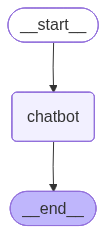

In [17]:
from IPython.display import Image, display
display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [18]:
# 단기 메모리 -> 대화 세션(thread) 에서 유지되는 메모리 -> invoke(), stream()으로 실행할 때 
## 대화 세션을 구분할 수 있는 식별값을 전달 -> thread_id, RunnableConfig에 넣어서 전달
config = {
    "configurable":{
        "thread_id":"diag-1" # key:thread_id, value: 대화 식별값
    }
}

In [19]:
res = graph.invoke(
    {"messages":[("human", "안녕하세요. 내 이름은 홍길동입니다.")]},
    config=config
)
res

{'messages': [HumanMessage(content='안녕하세요. 내 이름은 홍길동입니다.', additional_kwargs={}, response_metadata={}, id='da1a336a-ccd2-4f96-9ad5-c61b58677cb4'),
  AIMessage(content='안녕하세요, 홍길동님! 만나서 반갑습니다.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 17, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeDNJC8nOKPHq9F9xVx3gPj0HKz8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f45f2-bf23-7ee1-bd9f-b7ce319611ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 27, 'total_tokens': 44, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [23]:
res = graph.invoke(
    {"messages":[("human", "안녕하세요. 내 이름은 뭐야?")]},
    config=config
)

res

{'messages': [HumanMessage(content='안녕하세요. 내 이름은 홍길동입니다.', additional_kwargs={}, response_metadata={}, id='da1a336a-ccd2-4f96-9ad5-c61b58677cb4'),
  AIMessage(content='안녕하세요, 홍길동님! 만나서 반갑습니다.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 17, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeDNJC8nOKPHq9F9xVx3gPj0HKz8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f45f2-bf23-7ee1-bd9f-b7ce319611ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 27, 'total_tokens': 44, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [21]:
print(res['messages'][-1].content)

안녕하세요, 홍길동님! 만나서 반갑습니다.  
무엇을 도와드릴까요?


In [25]:
config2 = {
    "configurable":{"thread_id":"diag-2"}
}
res = graph.invoke(
    {"messages":[("human", "안녕하세요. 내 이름은 뭐야?")]},
    config=config2
)

res

{'messages': [HumanMessage(content='안녕하세요. 내 이름은 뭐야?', additional_kwargs={}, response_metadata={}, id='a921075e-ddfe-45ef-9226-4660acd5be29'),
  AIMessage(content='안녕하세요! 아직 당신의 이름은 제가 알 수 없어요.  \n원하시면 이름을 알려주시면 그다음부터 그렇게 불러드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 15, 'total_tokens': 53, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeH8deEXjuA0Fzo68O1Qn6AhYcOr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f45f6-51f8-7711-b0e1-c75abbb7d246-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 38, 'total_tokens': 53, 'input_token_details': {'audio': 0, 'cac

In [ ]:
#####
# create_agent()에서 checkpointer 지정
#####

In [26]:
system_prompt  = """
당신은 레스토랑 메뉴 정보와 일반적인 음식 관련 지식을 제공하는 AI 어시스턴트입니다. 
주요 목표는 사용자의 요청에 대한 정확한 정보를 제공하고 메뉴를 추천하는 것입니다.

주요 지침들(guidelines):
1. 레스토랑의 메뉴관련 정보를 확인하려면 search_menu_tool 도구를 사용하십시오. 이 도구는 레스토랑의 메뉴들의 가격, 음식의 특징들에 대한 정보를 제공합니다.
2. 사용자 요청한 음식에 menu에 없을 경우에는 tavily_search 도구를 이용해서 음식을 검색해서 추천합니다. 
3. 음식과 관련없는 요청 중에 최신정보가 필요한 경우에도 tavily_search 도구를 사용해서 정보를 검색해서 제공합니다.
4. 일반적인 음식 정보, 음식의 유래, 문화적 배경에 대한 정보는 search_wikipedia_korea 도구를 사용하십시오. 이 도구는 한국 wikipedia 에서 정보를 검색해서 제공합니다.
5. 검색 결과를 기반으로 명확하고 간결한 답변을 제공하십시오.
6. 요청 받은 질문이 모호하거나 필요한 정보가 부족한 경우 정중하게 설명을 요청하세요.
7. 메뉴 정보를 제공할 때는 가격, 주재료, 특징 순으로 설명하세요.
8. 메뉴를 추천 할 때는 간단하게 추천 이유를 설명해주세요.
9. 최종 응답은 챗봇과 같은 대화형 스타일을 유지하세요. 친근하고 매력적이며 자연스럽게 소통하되 전문성을 보이는 어조를 유지하세요.

- 각 도구의 목적과 기능을 정확하게 이해하고 각 적절한 상황에서 사용하세요.
- 각 도구들을 결합해서 사용자의 요청에 정확한 대답을 하세요.
- 항상 가장 최신의 정확한 정보를 제공하기 위해 노력하세요.
"""

In [30]:
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from tools import wikipedia_search_tool, search_menu_tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

# 툴들 정의
tavily_search = TavilySearch(max_results=5)
tools = [wikipedia_search_tool, search_menu_tool, tavily_search]

# 모델 정의
model = ChatOpenAI(model="gpt-5.4-mini")

checkpointer = InMemorySaver()

# Agent 생성
agent = create_agent(
    model=model,
    tools=tools, # 모델에 binding할 tools들 
    system_prompt=system_prompt,
    checkpointer=checkpointer
)

In [31]:
config = { "configurable": {"thread_id":"dialog-1"}}
res = agent.invoke(
    {"messages":[("human", "내일 서울 날씨?")]},
    config=config

)
res

{'messages': [HumanMessage(content='내일 서울 날씨?', additional_kwargs={}, response_metadata={}, id='0a8e288b-1df9-408b-a19c-c4c2b17f1615'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 1864, 'total_tokens': 1910, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeT3cT9WAhbdPPWo2FNu9VpAnC0G', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f4601-953b-7562-b52a-1f465c28b9a9-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '내일 서울 날씨', 'search_depth': 'fast', 'topic': 'general', 'include_images': False, 'time_range': 'day'}, 'id': 'call_H2BDeVRiybW9HmnvKzxK8wHH', 'type': 'tool_call'

In [32]:
config = { "configurable": {"thread_id":"dialog-1"}}
res = agent.invoke(
    {"messages":[("human", "날씨에 맞는 이태리 요리 추천")]},
    config=config

)
res

{'messages': [HumanMessage(content='내일 서울 날씨?', additional_kwargs={}, response_metadata={}, id='0a8e288b-1df9-408b-a19c-c4c2b17f1615'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 1864, 'total_tokens': 1910, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeT3cT9WAhbdPPWo2FNu9VpAnC0G', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f4601-953b-7562-b52a-1f465c28b9a9-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '내일 서울 날씨', 'search_depth': 'fast', 'topic': 'general', 'include_images': False, 'time_range': 'day'}, 'id': 'call_H2BDeVRiybW9HmnvKzxK8wHH', 'type': 'tool_call'

In [33]:
config = { "configurable": {"thread_id":"dialog-1"}}
res = agent.invoke(
    {"messages":[("human", "첫번째 추천 요리의 레시피?")]},
    config=config

)
res

{'messages': [HumanMessage(content='내일 서울 날씨?', additional_kwargs={}, response_metadata={}, id='0a8e288b-1df9-408b-a19c-c4c2b17f1615'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 1864, 'total_tokens': 1910, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzeT3cT9WAhbdPPWo2FNu9VpAnC0G', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f4601-953b-7562-b52a-1f465c28b9a9-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '내일 서울 날씨', 'search_depth': 'fast', 'topic': 'general', 'include_images': False, 'time_range': 'day'}, 'id': 'call_H2BDeVRiybW9HmnvKzxK8wHH', 'type': 'tool_call'

## 3. 장기 메모리 (Long-term memory)

- 장기 메모리는 **여러 대화 세션에 걸쳐 살아남는** 기억이다. 
- LLM이 대화에서 사용할 **지금까지 이어진 채팅에서 알게 된 사용자의 선호,정보**를 저장한 것을 장기 메모리라고 한다.

  - **사용 범위:** 모든 대화(스레드)에서 공유됨
  - **내용:** 사용자에 관한 사실, 선호, 과거 경험, 운영 규칙 등 모든 대화에서 사용할 수 있는 사용자 정보
  - **저장기간:** 명시적으로 지우기 전까지 영구적으로 보존

- 장기 메모리는 단순히 지금까지의 채팅내용을 저장하는 것이 아니라 사용자의 중요 정보를 추출해서 저장하는 것이다.
- **단기 메모리는** "**현재 이 대화에서 무슨 일이 일어나고 있는가**"를, **장기 메모리는** "**이 사용자에 대해 우리가 알게 된 것은 무엇인가**"를 기억하는 것이다. 
- 그래서 두 메모리는 **항상 분리해서 다루는 것**이 좋은 설계 원칙이다.

### 장기 메모리의 세 가지 유형

- 보통 장기 메모리는 다음과 같은 사항들을 저장한다.

1. **사용자에 관한 정보, 선호사항.**
   - 예를 들어 대화에서 "나는 윈도우즈를 쓰는 개발자인데, 질문에 대한 답변은 한국어로 해줘." 라는 메세지가 있었다면 "사용자의 사용 컴퓨터/OS 종류, 직업, 사용언어" 와 같은 정보를 추출 할 수 있다. 
   - 이 내용 장기 메모리로 저장한다.
    ```json
        {
            "os": "Windows",
            "occupation": "developer",
            "preferred_language": "Korean"
        }
    ```
    - 이 후 모든 새 대화(채팅)에서 위 기억을 시스템 프롬프트에 추가한다. 사용자가 "파이썬 가상환경 만드는 법 알려줘" 라고 질문하면, 알아서 Windows 기준의 명령어를 한국어로 답하게 된다.
  
2. **과거에 수행한 작업의 사례**
    - "전에 이런 작업을 이렇게 해결했다" 라고 하는 경험을 `그때 상황 → 그때 한 행동 → 그 결과`의 구조로 저장한다. **우리가 무엇을 해봤고 결과는 어떻게 됐는가** 를 저장하는 것이다.
    - 예를 들어 한 사용자에게 "SQL 쿼리 최적화를 도와줬고, 인덱스 힌트 방식이 효과적이었다" 라고 답을 했었다면
     ```json
        {
            "task": "SQL 쿼리 속도 개선",
            "approach": "인덱스 힌트 추가 + EXPLAIN ANALYZE로 검증",
            "outcome": "쿼리 시간 3.2초 → 0.4초",
            "context": "MySQL, 수백만 건 테이블, WHERE 절 다중 조건"
        }
     ```
    - 비슷한 요청이 들어오면 위 저장내용을 few-shot 예제처럼 프롬프트에 추가하여 llm이 참고하도록 한다.

3. **에이전트의 실행 규칙이나 지침**
    - Agent가 어떻게 실행할지를 저장한다. 
    - 보통 Agent가 어떻게 실행할지를 `시스템 프롬프트`로 작성한다. 다양한 대화 속에서 사용자의 피드백을 통해 에이전트가 이 프롬프트를 스스로 업데이트 한다
    - 예를 들어 논문을 검색, 요약해 주는 에이전트에서 초기 지침이 다음과 같았다고 하자.
    ```text
        - 사용자의 질문 키워드로 바로 논문 검색을 실행한다.
        - 상위 3편을 요약해 제공한다.
    ```
    - 질문이 모호해서 키워드 검색 결과가 너무 넓어 관련없는 논문이 섞이거나 3편만으로 핵심논문을 놓치는 경우가 많이 생겼다고 하자. 그래서 사용자가 이것에 대한 피드백을 했고 변경된 결과에 만족했다면 이 것을 통해 이 지침을 다음과 같이 변경할 수 있다.
    ```text
        - 검색 전, 질문에서 핵심 개념어와 제외할 단어를 먼저 분리한다.    # 추가됨
        - 검색 결과가 20편 이상이면 연도 필터(최근 5년)를 추가 적용한다.  # 추가됨
        - 인용 수 상위 5편과 최신 2편을 교차하여 요약한다.             # 수정됨
    ```

### 장기 메모리 기억(저장) 시점

- **핫 패스(hot path) 방식:** 
  - 응답을 생성하는 도중에, 모델이 직접 "이건 기억해 둬야겠다"고 판단해 즉시 저장한다. 
  - 새 기억이 곧바로 다음 턴부터 반영된다는 장점이 있지만, 무엇을 기억할지 판단하는 부담이 응답 지연(latency)으로 이어질 수 있다.
- **백그라운드(background) 방식:** 
  - 응답과 분리된 별도 작업으로 기억을 정리해 저장한다. 
  - 메인 응답이 느려지지 않고 로직이 깔끔하게 분리되지만, "언제 정리할지"를 따로 정해야 하고 그사이의 대화에는 새 기억이 반영되지 않는다.


### LangGraph에서 장기 메모리 관리

LangGraph에서는 일반적으로 **단기 메모리는 Checkpointer**를 사용하고, **장기 메모리는 Store를 사용하여 구현**한다. 단기 메모리가 스레드에 묶여 있던 것과 달리, 스토어의 데이터는 스레드 바깥에 따로 보관되어 **어느 대화에서든** 꺼내 쓸 수 있다.

- **Checkpointer** = **단기 메모리 관리**
- **Store** = **장기 메모리 관리**

#### Store의 기본 구조

LangGraph의 Store는 `namespace`, `key`, `value` 구조로 데이터를 저장한다.

|요소|의미|파일에 비유|
|-|-|-|
|namespace|데이터를 분류하는 경로|폴더 경로|
|key|namespace 안에서 데이터를 구분하는 이름|파일 이름|
|value|실제 저장할 데이터|파일 내용|

예를 들어 다음의 경우
```python
store.put(
    ("users", "user_123", "profile"), # namespace
    "basic_info",                     # key
    {                                 # value
        "role": "AI instructor",
        "language": "Korean"
    }
)
```
이 구조는 다음과 같은 계층 구조로 이해할 수 있다.
```text
users/
└── user_123/
    └── profile/
        └── basic_info
            └── {"role": "AI instructor", "language": "Korean"}
```

- **namespace**
    - namespace는 Store 안에서 데이터를 분류하기 위한 계층형 주소이다.
    - `("users", "user_123", "profile")` 의 경우
      - `사용자들` 중 `user_123 사용자`의 `profile 정보` 를 저장하는 공간으로 계층화 한다. 
    - namespace는 **tuple로 정의하며 길이의 제한은 없다.**
        ```
            ("users",) # 사용자 정보들을 저장하는 공간
            ("users", "user_123") # 사용자들 중 `user-123` 의 정보를 저장하는 공간
            ("users", "user_123", "profile") # 사용자 중 `user-123`의 `profile` 정보를 저장하는 공간
        ```
- **key**
    - key는 namespace 안에서 하나의 데이터를 구분하는 이름이다.
    - 같은 namespace 안에서는 각 기억들의 key는 서로 달라야 한다.
    - 예
        ```python
            store.put(
                ("users", "user_123", "preferences"),
                "response_style",
                {
                    "language": "Korean",
                    "tone": "clear",
                    "format": "markdown"
                }
            )
        ```
      - **namespace**: ("users", "user_123", "preferences")
      - **key**: "response_style"
      - **value**: {"language": "Korean", "tone": "clear", "format": "markdown"}


- **value**
    - value는 Store에 실제로 저장되는 데이터이다.
    - Value로는 문자열, 숫자, 리스트, 딕셔너리 등 JSON으로 직렬화 가능한 값을 저장할 수 있다. 일반적으로 실무에서는 **여러 속성을 함께 저장하기 위해 dict 형태를 가장 많이 사용**한다.
        ```python
            {
                "content": "사용자는 LangGraph 설명을 쉽게 정리하길 원한다.",
                "source": "conversation",
                "importance": 0.8
            }
        ```
- **장기메모리 예**
    - 사용자 선호 정보를 저장하는 예
        ```python
            store.put(
                ("users", "user_123", "preferences"),
                "response_style",
                {
                    "content": "사용자는 답변을 한국어로 받는 것을 선호한다.",
                    "language": "Korean",
                    "tone": "clear",
                    "format": "markdown"
                }
            )
        ```

    - 사용자 프로필 정보를 저장하는 예
        ```python
            store.put(
                ("users", "user_123", "profile"),
                "basic_info",
                {
                    "role": "AI Developer",
                    "main_topic": ["LangGraph", "LangChain", "Vector Database"]
                }
            )
        ```
#### Langgraph 공식 지원 Store (장기메모리 저장소)

- LangGraph가 공식적으로 제공하는 Store 구현체로 **InMemoryStore**, **SqliteStore**, **PostgresStore**가 있다.
- **InMemoryStore**: 데이터를 메모리(RAM)에 저장하므로 프로그램을 종료하면 사라진다. 프로토타이핑·테스트용으로 적합하다.
- **SqliteStore**: SQLite(파일 기반 DB)에 저장하므로 영구 보관이 가능하다. 별도의 DB 서버가 필요 없어 단일 머신·소규모 환경에 적합하다.
- **PostgresStore**: PostgreSQL에 저장하므로 영구 보관이 가능하다. 동시 접근과 확장성이 필요한 실제 운영(서버) 환경에서 권장된다.
- InMemoryStore는 langgraph 코어에 포함되지만 SqliteStore, PostgresStore는 각각 `langgraph-checkpoint-sqlite`,`langgraph-checkpoint-postgres` 패키지 설치가 필요하다

##### InMemoryStore 예

- **Store 생성 및 연결**
  - Graph와 Store 연결은 graph compile 때 설정한다.   
  
    ```python
    from langgraph.store.memory import InMemoryStore
    
    store = InMemoryStore()
    graph = builder.compile(store=store)
    ```
    - 실제 서비스에서는 체크포인터(단기)와 스토어(장기)를 **함께** 연결하는 것이 일반적이다. 

    ```python
    graph = builder.compile(checkpointer=checkpointer, store=store)
    ```
- **Node에서 Store 접근**
  - `Runtime`을 이용하는 방법과 `langgraph.config.get_store()` 를 이용하는 방법이 있다.
  - 보통Graph 안의 node에서는 `runtime.store`로 Store에 접근한다.
    - `Runtime` 은 **그래프 실행 시 LangGraph가 노드에게 제공하는 실행 환경 정보 객체** 이다. node 함수의 두번째 파라미터로 변수를 선언하면 그래프 실행 시 전달된다. 이것을 통해 **store**, **context**, **config** 정보등을 조회할 수 있다.
        ```python
        def answer_node(state: State, runtime: Runtime):
            ...
            runtime.store.get(namespace, key) # 조회
            runtime.store.put(namespace, key, value) # 저장
        ```
  - `get_store()` 사용
    - **현재 실행 중인 LangGraph 그래프에 연결된 Store 객체를 가져오는 함수**이다.
    - Node에서는 `get_store()` 나 `Runtime`을 이용해 Store를 접근할 수있다. 그러나 **Tool 의 경우는 Runtime을 받지 않기 때문에 주로 get_store()를 사용한다.**
        ```python
        from langchain_core.tools import tool
        from langgraph.config import get_store

        @tool
        def save_user_preference(text: str):

            store = get_store()

            store.put(
                ("users", "user1", "preferences"),
                "favorite",
                {"text": text}
            )

            return "저장 완료"

        ```
##### Store 데이터 관리

- Store에서는 데이터를 저장, 조회, 검색, 수정, 삭제할 수 있다.

| 작업 | 메서드   | 주요 파라미터                  | 설명 |
| --- | ------- | --------------------------- | ---------------------------------------------------------------------------------------------------------- |
| 저장 | `put()` | `namespace`, `key`, `value` | 지정한 `namespace`와 `key`에 데이터를 저장한다. 같은 위치에 데이터가 없으면 새로 추가하고, 이미 있으면 기존 값을 갱신한다. |
| 조회 | `get()` | `namespace`, `key`          | 정확한 `namespace`와 `key`로 하나의 데이터를 가져온다. 저장 위치와 key를 정확히 알고 있을 때 사용한다. |
| 검색 | `search()` | `namespace`, `query`, `filter`, `limit` | 지정한 `namespace` 범위에서 여러 데이터를 검색한다. `query`는 관련도 또는 의미 기반 검색에 사용할 수 있고, `filter`는 특정 필드 조건으로 검색할 때 사용한다. key를 모르거나 관련 항목을 찾을 때 사용한다. |
| 수정 | `put()` | `namespace`, `key`, `value` | 같은 `namespace`와 `key`에 새로운 `value`를 다시 저장해 기존 데이터를 갱신한다. |
| 삭제 | `delete()` | `namespace`, `key`       | 지정한 `namespace`와 `key`에 해당하는 데이터를 삭제한다. |


- **저장(추가)하기**
  - 예) users/user_123/preferences/response_style 위치에 사용자의 답변 스타일 정보를 저장한다.
        ```python
        store.put(
            ("users", "user_123", "preferences"),
            "response_style",
            {
                "language": "Korean",
                "tone": "clear",
                "format": "markdown"
            }
        )
        ```


- **조회하기**
    - 정확한 namespace와 key를 알고 있을 때는 `get()`을 사용한다. 결과는 `Item` 객체로 반환하고 조회결과가 없으면 `None`을 반환한다.
      - `Item`은 조회한 namespace, key, value 등을 속성으로 가진다.
    - 예)
        ```python
            item = store.get(
                ("users", "user_123", "preferences"),
                "response_style"
            )
            print(item.value)
        ```
        ```text
            # 출력 결과
            {
                "language": "Korean",
                "tone": "clear",
                "format": "markdown"
            }
        ```
- **검색하기**
    - **query**: 의미기반(벡터) 검색
      - 의미기반 검색을 위해서는 store에 **semantic index**가 설정되어 있어야 한다.
            ```python
            embeddings = init_embeddings("openai:text-embedding-3-small")
            store = InMemoryStore(index={
                        "embed": embeddings,
                        "dims": 1536,
                    }
            )
            ```
    - 예) users/user_123/memories 네임스페이스에서 "Langgraph 수업 자료" 와 관련된 내용을 3개 검색
        ```python
            items = store.search(
                ("users", "user_123", "memories"),
                query="LangGraph 수업 자료",
                limit=3
            )
            for item in items:
                print(item.key)
                print(item.value)
        ```
    - **filter**: 조건 검색
      - 예) value의 'topic' 이 'LangGraph' 인 것을 10개 조회
        ```python
            items = store.search(
                ("users", "user_123", "memories"),
                filter={"topic": "LangGraph"},
                limit=10
            )
        ```
    - query와 filter를 같이 사용할 수 있다.

- **수정하기**

    - Store에서 수정은 put()으로 처리한다.
    - 같은 namespace와 같은 key에 다시 저장하면 기존 값이 갱신된다.
        ```python
            store.put(
                ("users", "user_123", "preferences"),
                "response_style",
                {
                    "language": "Korean",
                    "tone": "concise",
                    "format": "markdown"
                }
            )
        ```
        
- **삭제하기**
    - 저장된 메모리를 삭제할 때는 delete()를 사용한다.
    - 예)
    ```python
        store.delete(
            ("users", "user_123", "preferences"),
            "response_style"
        )
    ```


In [ ]:
from langgraph.store.sqlite import SqliteStore
from langchain_openai import OpenAIEmbeddings
import os

os.makedirs('longterm_memory', exist_ok=True)
with SqliteStore.from_conn_string(
    "ltm.db",
    index={
                "dims": 1536,
                "embed": OpenAIEmbeddings(),
                "fields": ["text"]
            }
) as store:
    store.setup()

    # 저장
    store.put(
        ("users", "user_123", "preferences"),
        "response_style",
        {"language": "Korean", "tone": "clear", "format": "markdown", "style": "simple"}
    )

    store.put(
        ("users", "user_123", "information"),
        "basic_info",
        {"name": "이순신", "age": 25, "email": "leess@example.com"}
    )

    store.put(
        ("users", "user_321", "preferences"),
        "response_style",
        {"language": "English", "tone": "kindly", "format": "xml", "style": "simple"}
    )
    store.put(
        ("users", "user_321", "information"),
        "basic_info",
        {"name": "유관순", "age": 33, "email": "ruyks@example.com"}
    )

    item = store.get(("users", "user_123", "preferences"), "response_style")
    if item:
        print(item.value)   # {'language': 'Korean', 'tone': 'clear', 'format': 'markdown'}
    else:
        print("Item not found")
   
    ##################################
    #  search() - filter
    ##################################
    
    

    #################################
    #  search() - filter 비교 연산 - $eq, $ne, $gt, $lt, $gte, $lte
    #################################
    
    


    ##################################
    #  search() - query (의미기반 검색)
    ##################################
    
    
    

# Human In The Loop (HITL)

- **Human-In-The-Loop**(**HITL**)은 AI 시스템의 의사결정 과정에 **사람이 직접 개입하여 검증, 승인, 수정, 피드백**을 제공하는 설계 패턴이다.
- LangGraph에서의 HITL은 **그래프**(**에이전트 워크플로우**)**의 특정 노드를 실행 중단**(**pause**)하고, 그 지점에서 사람의 입력을 받아 **다음 실행 방향을 결정하거나 상태(State)를 변경**한 뒤 흐름을 이어가는 방식으로 동작한다.

## HITL의 핵심 특성

 특성              | 설명                                              |
| --------------- | --------------------------------------------------------------------------- |
| 워크플로우 일시정지      | interrupt(중단) 기능으로 그래프 실행을 특정 노드에서 멈춤           |
| 상태(State) 수정 가능 | 사람이 중간 결과를 보고 State 값을 변경할 수 있음                 |
| 승인/거절/대안 흐름 선택  | 다음 엣지(경로)를 사람이 결정할 수 있음                         |
| 체크포인트 기반 복구     | 체크포인트(checkpoint) 시스템으로 이전 실행 지점으로 되돌리거나 재실행 가능 |
| 멀티 턴 인터랙션       | 필요 시 여러 번 사람과 상호작용 가능                           |

## HITL 사용 시점(Usecase)
HITL은 **사람의 판단이 필요한 고위험(high-stakes) 순간**, **맥락 기반 검증이 중요한 경우**, 또는 **AI 단독으로는 신뢰를 완전히 담보하기 어려운 경우**에 사용한다.

1. **결과 승인**
   - AI가 생성한 답변을 사람이 확인 후 승인해야 다음 단계로 진행
   - 예: 이메일 발송 전 내용 확인, 회사 계좌로 송금하기 전 최종 승인, 프로덕션 코드 배포 전 리뷰.
2. **모호성 해결 및 명확화**
   - 사용자 요청이 모호할 때 명확히 하기 위해 확인
    - 예: "사용자가 '그거 예약해줘'라고 했는데, '그거'가 무엇인지 AI가 모를 때 사람에게 물어봄."
3. **데이터 보정(중간 결과물 수정)**
   - AI가 추출한 정보가 애매하거나 추가 데이터가 필요한 경우 사람이 직접 수정 
   - 예: AI가 작성한 블로그 초안을 사람이 검토하고 수정한 뒤, 다시 AI에게 발행을 맡길 때.
4. **정책/규제 준수 검증**
   - 예: 금융, 의료, 법률 등 도메인에서 사람 검토 필수
5. **도구 실행 전 확인**
   - 예: 이메일 발송, DB 삭제, 결제 실행 등 AI가 액션을 수행하기 전 사람 승인
6. **학습 피드백**
   - 예: 모델이 틀렸을 경우 사람이 직접 피드백을 주고 흐름 재조정

## 관련 주요 API

| API                          | 역할                                        | 사용 목적                                   |
| ---------------------------- | ------------------------------------------- | -----------------------------------------   |
| `interrupt()`                | 현재 그래프 실행을 중단하고 외부 입력을 대기| 사람의 검토/입력을 받기 위해 그래프를 멈춤  |
| `Checkpointer` | 실행 지점을 저장하는 체크포인트를 반드시 사용해야 한다. | 이전 상태로 되돌리거나 중단 지점부터 재실행 하기 위해 상태가 저장되어 있어야 한다.|
| `invoke()`/`stream()`        | 그래프 실행 시작 또는 재개                  | HITL 입력 후 다시 실행                      |
| `Command(resume=...)`        | 재개 명령                                   | interrupt로 멈춘 곳에 사람의 입력값을 전달하며 실행을 다시 시작함 |
| `graph.update_state()`       | 상태(State) 수정                            | interrupt 되어 있는 동안 사람이 직접 state를 수정 할 수있게 한다.|


## 실행을 중단하는 두가지 방식
- 노드에서 `interrupt()` 를 호출 하여 명시적으로 멈춘다. (Dynamic Interrupt)
  - `interrupt()` 로 일시적으로 멈추면 그때 까지의 state snapshot이 반환 되며 **state 에는 `"__interrupt__"` key에 멈춤 정보(Interrupt객체)가 포함**되어 있다.
- Graph 컴파일시 `interrupt_before` 설정으로 노드를 지정하여 특정 노드가 실행하기 직전에 무조건 멈추게 한다. (Static Interrupt)
- **최신 버전에서는 Dynamic Interrupt 방식을 선호한다.**